In [ ]:
#| default_exp datasource_ex 

In [ ]:
#| hide
from nbdev.showdoc import *
from nbdev import show_doc
from fhemb.dbms.db import Datasource
from fhemb.utils.factories import ConcreteEmbFactory

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db


In [ ]:
#| hide
#| export

from nbdev_fhemb.piece_ex import dg0

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 42), 50, (65, 68)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 50, 65, 66, 67, 68] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 50, 65, 66, 67, 68]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 42), 50, (65, 68)]


# Embed a Datasource

> Time series of arrays from a Datasource

## Inspect the Datasource

### Metadata of the underlying `Peace`

In [ ]:
#| eval: false

dg0.facebbox_t.piece_attributes

 [INFO] piece._load_from_db: Loading facebbox_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj40, subj41, subj42, subj50, subj65, subj66, subj67, subj68 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 15200 ORDER BY frame_number
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/paramiko/pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/paramiko/transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,
 [DEBUG] piece.start: SSH tunnel established
 [DEB

{'piece': 'Don Giovanni',
 'temperature_threshold': 25,
 'percentile_interval': 5,
 'normalize_histogram': True,
 'norm_face_size': 1500,
 'sub_roi_width': 5,
 'resize': (40, 60),
 'db_schema': 'dg',
 'number_of_subjects': 77}

### Data of the `Datasource`
>which is a time series of 2d arrays the shape of which is not stationary, i.e., the grid of heatmaps is evolving.  

In [ ]:
#| eval: false

dg0.facebbox_t.features_tint['subj40'][0].shape, dg0.facebbox_t.features_tint['subj40'][10].shape

((21, 16), (22, 16))

#### Depict the probability distribution 
> for a specified subject and times

In [ ]:
#| hide
#| eval: false

import plotly.io as pio

In [ ]:
#| hide
#| eval: false
pio.renderers.default = "png"

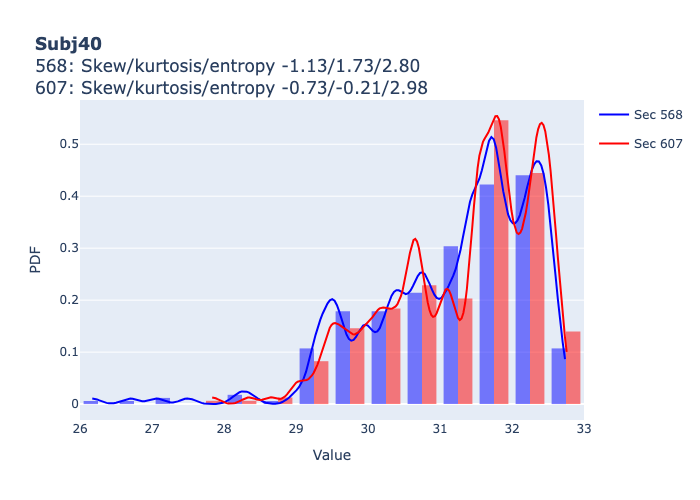

In [ ]:
#| eval: false

dg0.facebbox_t.plot_pdf(subj=40, secs=[568, 607], bw_method=0.1)

## Create Embeddings

### Simple embeddings

#### The positions of face is a trivial *vector* embedding - a series of $(x, y)$ coordinates

In [ ]:
#| eval: false

dg0.facebbox_t.position.features_tint['subj40'].shape

(2, 1000)

#### Percentiles are an example of a *vector* embedding - a series of $(p0, \ldots, p100)$ tuples

In [ ]:
#| eval: false

dg0.facebbox_t.percentiles_ts

 [INFO] piece._derive_features: Deriving binheights_ts, binedges, percentiles_ts, and features_ts
 [DEBUG] piece._cache_derived_features: Creating binhieghts_ts Embedding
 [DEBUG] embedding.__init__: Creating a BaseEmbedding with time_interval=(14200, 15200), subjects=None
 [DEBUG] embedding.__init__: Subjects: ['subj40', 'subj41', 'subj42', 'subj50', 'subj65', 'subj66', 'subj67', 'subj68']
 [DEBUG] embedding.__init__: No features provided, using all features from the first subject prefixed with bh
 [DEBUG] piece._cache_derived_features: Creating binedges
 [DEBUG] piece._cache_derived_features: Creating percentiles_ts Embedding
 [DEBUG] embedding.__init__: Creating a BaseEmbedding with time_interval=(14200, 15200), subjects=None
 [DEBUG] embedding.__init__: Subjects: ['subj40', 'subj41', 'subj42', 'subj50', 'subj65', 'subj66', 'subj67', 'subj68']
 [DEBUG] embedding.__init__: No features provided, using all features from the first subject prefixed with p
 [DEBUG] piece._cache_derived_fe

<fhemb.embedding.Embedding>

### PCA *eigenfaces* embedding

#### 1. Define PCA 

In [ ]:
#| exporti

from fhemb.utils.factories import wfactory, pca_factory

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db


In [ ]:
#| exports
#| eval: false

pca = pca_factory(
    name='standard_kpca_5_sigmoid_0.1',   # specify name for your references
    scaler='Standard',                    # specify a scaler for preprocessing
    pca='Kernel',                         # specify a type of the PCA 
    scaler_kwargs=dict(with_std=False),   # specify parameters for the scaler
    pca_kwargs=dict(n_components=5, kernel='sigmoid', gamma=.07, fit_inverse_transform=True)  # specify parameters for the PCA
) 


####  2. Create the embedding

##### a) On array-shape *stationary* time series
> For example the array-shape in *face_t* is fixed over time

In [ ]:
#| eval: false

dg0.face_t.create_pca_embedding(factory=pca)

 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])
 [DEBUG] tutils.create: Using already calculated value for StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0)


(<fhemb.embedding.Embedding>,
 "StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0)")

##### b) On array-shape *non-stationary* time seris
>The array shapes need to be normalized (made stationary) by calling `.rsfacebbox`, $$\mathrm{Datasource} \rightarrow \mathrm{Datasource}\enspace,$$ which resizes `facebbox_t`   

In [ ]:
#| eval: false

dg0.facebbox_t.rsfacebbox_t.create_pca_embedding(factory=pca)

 [DEBUG] piece.create_pca_embedding: Calling create_pca_embedding
 [DEBUG] tutils.create: Creating create_pca_embedding with args: StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0) and kwargs: dict_keys(['factory', 'datasource', 'subjects', 'time_interval', 'temperature_threshold'])
 [DEBUG] tutils.create: Calculating create_pca_embedding for StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0)
 [DEBUG] factories.fit_pipe: Fitting PCA on data with shapes: [(1000, 2400), (1000,

(<fhemb.embedding.Embedding>,
 "StandardScaler(copy=True,with_mean=True,with_std=False) | KernelPCA(alpha=1.0,coef0=1,copy_X=True,degree=3,eigen_solver='auto',fit_inverse_transform=True,gamma=0.07,iterated_power='auto',kernel='sigmoid',kernel_params=None,max_iter=None,n_components=5,n_jobs=None,random_state=None,remove_zero_eig=False,tol=0)")